#Data Downloading

In [ ]:
!pip install yFinance

In [ ]:
def save_data(df):
    df.to_csv("aapl.csv", index = False)

import yfinance as yf
data = yf.download("AAPL",
                   start = "2000-01-01",
                   end = "2026-01-01",
                   auto_adjust = False)

data.columns = data.columns.get_level_values(0)
data.reset_index(inplace = True)
data = data[[
    "Date", "Open", "High", "Low", "Close", "Volume"
]]
save_data(data)

print(data.shape)

[*********************100%***********************]  1 of 1 completed

(6539, 6)


#Data Information

In [ ]:
import pandas as pd

df = pd.read_csv("aapl.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,2000-01-03,0.936384,1.004464,0.907924,0.999442,535796800
1,2000-01-04,0.966518,0.987723,0.903460,0.915179,512377600
2,2000-01-05,0.926339,0.987165,0.919643,0.928571,778321600
3,2000-01-06,0.947545,0.955357,0.848214,0.848214,767972800
4,2000-01-07,0.861607,0.901786,0.852679,0.888393,460734400


In [ ]:
import pandas as pd

df = pd.read_csv("aapl.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6539 entries, 0 to 6538
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6539 non-null   object 
 1   Open    6539 non-null   float64
 2   High    6539 non-null   float64
 3   Low     6539 non-null   float64
 4   Close   6539 non-null   float64
 5   Volume  6539 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 306.6+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Volume
count,6539.000000,6539.000000,6539.000000,6539.000000,6.539000e+03
mean,49.932780,50.471761,49.426715,49.972447,3.732367e+08
std,69.677359,70.424229,69.000277,69.748310,3.816933e+08
min,0.231964,0.235536,0.227143,0.234286,1.791060e+07
25%,2.565179,2.590893,2.524107,2.557500,1.061800e+08
50%,18.501785,18.648571,18.306786,18.536072,2.525152e+08
75%,53.966249,54.596251,53.208750,53.818750,5.012210e+08
max,286.200012,288.619995,283.299988,286.190002,7.421641e+09


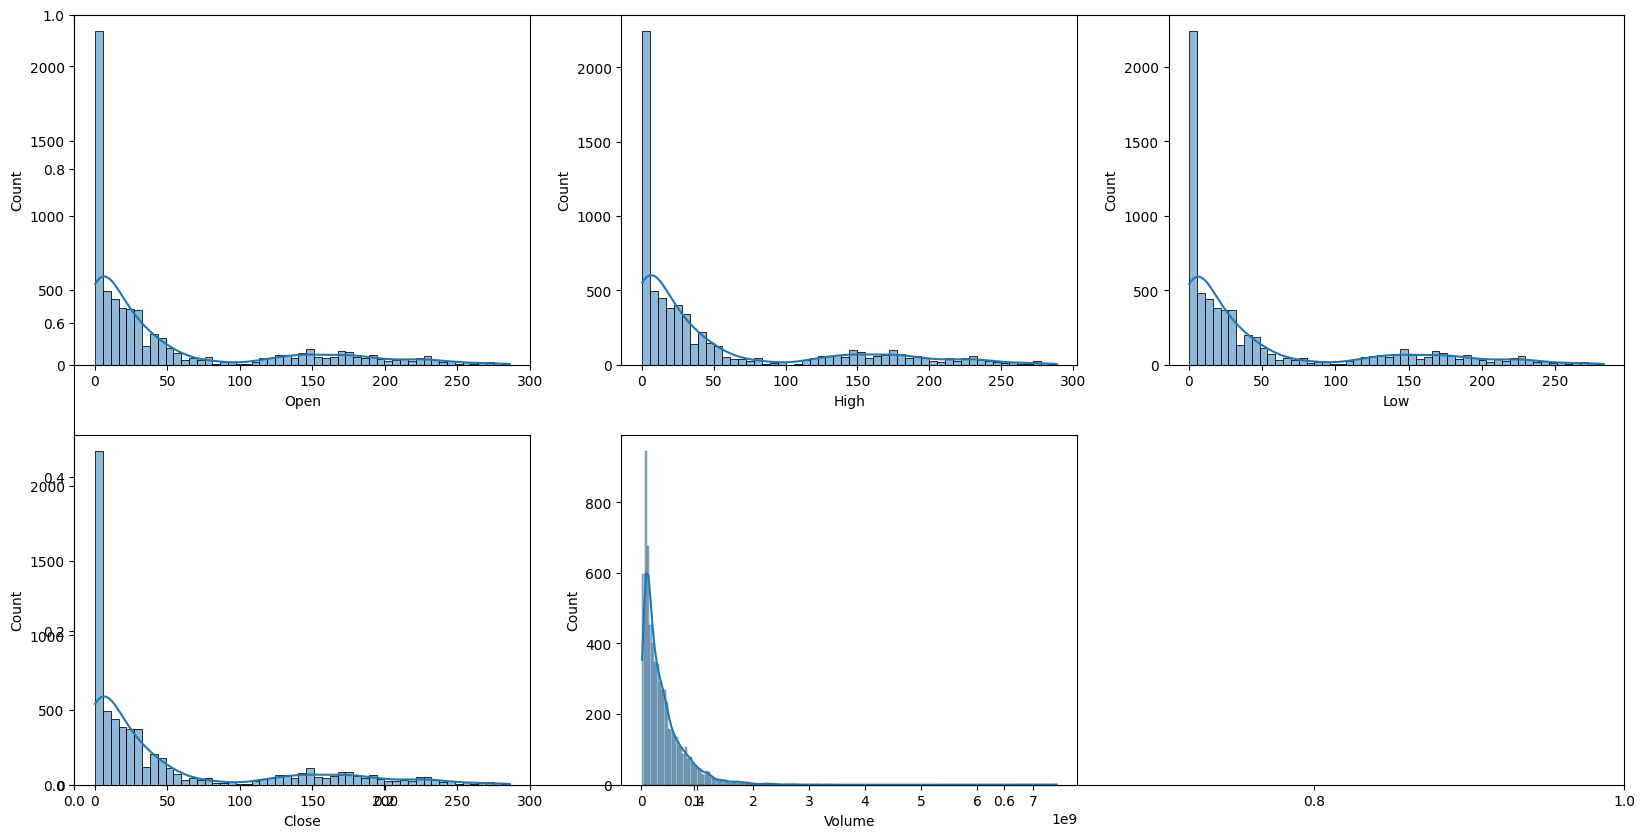

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.histplot(df[col], kde = True)
plt.show()

#Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np

def checking_columns(df):
    required = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    missing = [col for col in required if col not in df.columns]

    if missing:
        print(f"Mssing required column, {missing}")
    else:
        print("All required columns exist")

    print()
    print("--------------------------------------------------------------------------------------------------------")
    print()
    return df


def handling_null(df):
    print("Mssing before: /n", df.isnull().sum())

    price_cols = ["Open", "High", "Low", "Close"]
    df[price_cols] = df[price_cols].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    df.dropna(inplace = True)

    print("Missing after: /n", df.isnull().sum())
    print()
    print("--------------------------------------------------------------------------------------------------------")
    print()
    return df


def remove_outliers(df):
    print("length before: ", len(df))

    from scipy import stats
    z_score = np.abs(stats.zscore(df['Close']))
    df = df[z_score <= 4]

    print("Length after: ", len(df))
    print()
    print("--------------------------------------------------------------------------------------------------------")
    print()
    return df


def save_preprocessed(df):
    df.to_csv("aapl_preprocessed.csv")
    return df


def report(df):
    print(f"  Shape         : {df.shape}")
    print(f"  Date range    : {df.index[0]} → {df.index[-1]}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Columns       : {list(df.columns)}")
    print("\n First 5 rows:")
    print(df.head())
    print("\n  Last 5 rows:")
    print(df.tail())
    print("\n  Return statistics:")
    print(df.describe())
    print()
    print("--------------------------------------------------------------------------------------------------------")
    print()


def preprocessing(df):
    df = checking_columns(df)
    df = handling_null(df)
    df = remove_outliers(df)
    df = save_preprocessed(df)
    report(df)
    return df


data = pd.read_csv("aapl.csv", index_col="Date", parse_dates=True)
preprocessing(data)

Mssing required column, ['Adj Close']

--------------------------------------------------------------------------------------------------------

Mssing before: /n Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Missing after: /n Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

--------------------------------------------------------------------------------------------------------

length before:  6539
Length after:  6539

--------------------------------------------------------------------------------------------------------

  Shape         : (6539, 5)
  Date range    : 2000-01-03 00:00:00 → 2025-12-31 00:00:00
  Missing values: 0
  Columns       : ['Open', 'High', 'Low', 'Close', 'Volume']

 First 5 rows:
                Open      High       Low     Close     Volume
Date                                                         
2000-01-03  0.936384  1.004464  0.907924  0.999442  535796800
2000-01-04  0.966518  0.987723  0.903460  0.915

,Open,High,Low,Close,Volume
Date,,,,,
2000-01-03,0.936384,1.004464,0.907924,0.999442,535796800
2000-01-04,0.966518,0.987723,0.903460,0.915179,512377600
2000-01-05,0.926339,0.987165,0.919643,0.928571,778321600
2000-01-06,0.947545,0.955357,0.848214,0.848214,767972800
2000-01-07,0.861607,0.901786,0.852679,0.888393,460734400
...,...,...,...,...,...
2025-12-24,272.339996,275.429993,272.200012,273.809998,17910600
2025-12-26,274.160004,275.369995,272.859985,273.399994,21521800
2025-12-29,272.690002,274.359985,272.350006,273.760010,23715200


#Feature Engineering

In [ ]:
import numpy as np
import pandas as pd


# ===== CORE FEATURES =====

def add_returns(df):
    df["return_1"] = df["Close"].pct_change(1)
    df["return_2"] = df["Close"].pct_change(2)
    df["return_acc"] = df["return_1"].diff()
    print("Returns added")
    return df


def add_momentum(df):
    df["momentum_3"] = df["Close"] / df["Close"].shift(3) - 1
    df["momentum_7"] = df["Close"] / df["Close"].shift(7) - 1
    df["momentum_14"] = df["Close"] / df["Close"].shift(14) - 1
    df["momentum_change"] = df["momentum_3"].diff()
    return df

def smooth_features(df):
    for col in ["return_1", "return_2", "momentum_3", "momentum_7", "momentum_14"]:
        df[f"{col}_smooth"] = df[col].rolling(3).mean()
    return df

def add_long_trend(df):
    df["trend_20"] = df["Close"].pct_change(20)
    df["trend_30"] = df["Close"].pct_change(30)
    return df

def add_price_transforms(df):
    df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]
    df["oc_change"] = (df["Close"] - df["Open"]) / df["Open"]
    print("Price transforms added")
    return df


def transform_volume(df):
    df["Volume"] = np.log1p(df["Volume"])
    print("Volume transformed")
    return df

def add_ema_features(df):
    df["ema_10"] = df["Close"].ewm(span=10).mean()
    df["ema_20"] = df["Close"].ewm(span=20).mean()

    df["ema_diff"] = df["ema_10"] - df["ema_20"]
    df["price_vs_ema"] = df["Close"] - df["ema_10"]

    return df


def add_volatility_feature(df):
    df["volatility_3"] = df["Close"].pct_change().rolling(3).std()
    df["volatility_10"] = df["Close"].pct_change().rolling(10).std()
    return df


def add_volume_features(df):
    df["vol_change"] = df["Volume"].pct_change()

    df["vol_spike"] = (
        df["vol_change"] > df["vol_change"].rolling(10).mean()
    ).astype(int)

    return df


def add_price_position(df):
    rolling_min = df["Close"].rolling(20).min()
    rolling_max = df["Close"].rolling(20).max(0)
    df["price_norm"] = df["Close"] / df["Close"].rolling(20).mean()
    df["price_position"] = (df["Close"] - rolling_min) / (rolling_max - rolling_min)

    return df



# ===== INDICATORS =====

def add_rsi(df, period=14):
    diff = df['Close'].diff()
    gains = diff.clip(lower=0)
    losses = -diff.clip(upper=0)

    avg_gains = gains.ewm(com=period - 1, min_periods=period).mean()
    avg_losses = losses.ewm(com=period - 1, min_periods=period).mean()

    rs = avg_gains / avg_losses
    df["RSI"] = 100 - (100 / (1 + rs))

    return df


def add_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    df["MACD"] = ema_fast - ema_slow
    df["MACD_Signal"] = df["MACD"].ewm(span=signal, adjust=False).mean()

    return df


def add_bollinger_bands(df, period=20, std_dev=2):
    df["BB_Middle"] = df["Close"].rolling(window=period).mean()
    rolling_std = df["Close"].rolling(window=period).std()

    df["BB_Upper"] = df["BB_Middle"] + (std_dev * rolling_std)
    df["BB_Lower"] = df["BB_Middle"] - (std_dev * rolling_std)

    df["BB_Width"] = (df["BB_Upper"] - df["BB_Lower"]) / df["BB_Middle"]
    df["BB_Pct"] = (df["Close"] - df["BB_Lower"]) / (df["BB_Upper"] - df["BB_Lower"])

    df.drop(["BB_Upper", "BB_Lower"], axis=1, inplace=True)

    return df


def add_volatility(df):
    df["volatility_10"] = df["Close"].pct_change().rolling(10).std()
    return df


def add_trend_feature(df):
    df["trend_5"] = df["Close"].pct_change(5)
    df["trend_10"] = df["Close"].pct_change(10)
    return df


# ===== CLEANUP =====

def final_cleanup(df):
    df.dropna(inplace=True)
    return df


# ===== MAIN PIPELINE =====

def feature_engineering(df):

    df = add_returns(df)
    df = add_momentum(df)
    df = smooth_features(df)
    df = add_long_trend(df)
    df = add_price_transforms(df)
    df = transform_volume(df)
    df = add_ema_features(df)
    df = add_volatility_feature(df)
    df = add_volume_features(df)
    df = add_price_position(df)

    df = add_rsi(df)
    df = add_macd(df)
    df = add_bollinger_bands(df)
    df = add_volatility(df)
    df = add_trend_feature(df)

    df = final_cleanup(df)

    df.to_csv("aapl_with_indicators.csv")
    print("Final dataset ready")

    return df


if __name__ == "__main__":
    data = pd.read_csv(
        "aapl_preprocessed.csv",
        index_col="Date",
        parse_dates=True
    )

    data = feature_engineering(data)
    print(data.shape)

Returns added
Price transforms added
Volume transformed
Final dataset ready
(6509, 39)


#Adding target columns

In [ ]:
import pandas as pd

def add_magnitude_target(df, horizon = 10):
    df["target_magnitude"] = df["Close"].shift(-horizon) / df["Close"] - 1
    return df


def add_direction_target(df, horizon = 10):
    future_return = df["Close"].shift(-horizon) / df["Close"] - 1
    df["target_direction"] = (future_return > 0).astype(int)
    return df


# CLEANUP
def cleanup(df):
    before = len(df)
    df.dropna(inplace = True)
    after = len(df)

    print(f"Dropped {before - after} rows due to NaNs")
    return df


# SAVE
def save_data(df):
    df.to_csv("aapl_final.csv")
    print("Final dataset saved")
    return df


# MAIN PIPELINE
def create_targets(df):
    df = add_magnitude_target(df, horizon = 10)
    df = add_direction_target(df, horizon = 10)

    df = cleanup(df)
    df = save_data(df)

    return df


if __name__ == "__main__":
    data = pd.read_csv(
        "aapl_with_indicators.csv",
        index_col = "Date",
        parse_dates = True
    )

    create_targets(data)

print(data["target_direction"].value_counts(normalize = True))

Dropped 10 rows due to NaNs
Final dataset saved
target_direction
1    0.585321
0    0.414679
Name: proportion, dtype: float64


#Scaling

In [ ]:
import pandas as pd

def split_data(df, train_ratio = 0.7, val_ratio = 0.15):

    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * val_ratio) + train_end

    train = df.iloc[:train_end].copy()
    val   = df.iloc[train_end:val_end].copy()
    test  = df.iloc[val_end:].copy()

    print("Splitting done \n")
    print("n:", n)
    print("Train length:", len(train))
    print("Test length:", len(test))
    print("Val length:", len(val))

    return train, val, test


def scale_data(df, train, val, test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()

    target_cols = ['target_magnitude', 'target_direction']
    features = [
    "return_1",
    "momentum_3",
    "momentum_7",
    "momentum_14",
    "momentum_3_smooth",
    "trend_20",
    "trend_30",
    "ema_diff",
    "volatility_10",
    "price_position",
    "vol_spike",
    "volatility_3",
    "return_acc",
    "momentum_change",
    "price_norm"
]
    print(f"Feature Columns: {features}")

    train[features] = scaler.fit_transform(train[features])
    val[features]   = scaler.transform(val[features])
    test[features]  = scaler.transform(test[features])

    return train, val, test, scaler, features


def save_scaler(scaler):
    import pickle
    with open("scaler.pkl", 'wb') as f:
        pickle.dump(scaler, f)
    print("Scaler saved")


def save_splits(train, val, test):
    train.to_csv('train.csv', index = True)
    val.to_csv('val.csv', index = True)
    test.to_csv('test.csv', index = True)

    return  train, val, test



data = pd.read_csv('aapl_final.csv', index_col = 'Date', parse_dates = True)
train, val, test = split_data(data, train_ratio = 0.7, val_ratio = 0.15)
train, val, test, scaler, features = scale_data(data, train, val, test)
save_scaler(scaler)
save_splits(train, val, test)

Splitting done 

n: 6499
Train length: 4549
Test length: 976
Val length: 974
Feature Columns: ['return_1', 'momentum_3', 'momentum_7', 'momentum_14', 'momentum_3_smooth', 'trend_20', 'trend_30', 'ema_diff', 'volatility_10', 'price_position', 'vol_spike', 'volatility_3', 'return_acc', 'momentum_change', 'price_norm']
Scaler saved


(                 Open       High        Low      Close     Volume  return_1  \
 Date                                                                          
 2000-02-15   1.029018   1.070871   1.028460   1.062500  20.001192  1.019873   
 2000-02-16   1.051339   1.054688   1.001116   1.018973  19.751056 -1.631581   
 2000-02-17   1.028460   1.031250   1.010045   1.025670  19.483658  0.208802   
 2000-02-18   1.023438   1.030134   0.989955   0.993304  19.268443 -1.267267   
 2000-02-22   0.983259   1.044085   0.952567   1.016183  19.861217  0.846054   
 ...               ...        ...        ...        ...        ...       ...   
 2018-03-09  44.490002  45.000000  44.347500  44.994999  18.673312  0.619493   
 2018-03-12  45.072498  45.597500  45.052502  45.430000  18.673992  0.328635   
 2018-03-13  45.647499  45.875000  44.810001  44.992500  18.657917 -0.418450   
 2018-03-14  45.080002  45.130001  44.452499  44.610001  18.581724 -0.374751   
 2018-03-15  44.625000  45.060001  44.51

#Windowing

In [ ]:
import numpy as np
import pandas as pd


def create_windows(df, window_size = 30):
    target_cols  = ["target_direction", "target_magnitude"]
    feature_cols = [
    "return_1",
    "momentum_3",
    "momentum_7",
    "momentum_14",
    "momentum_3_smooth",
    "trend_20",
    "trend_30",
    "ema_diff",
    "volatility_10",
    "price_position",
    "vol_spike",
    "volatility_3",
    "return_acc",
    "momentum_change",
    "price_norm"
]

    print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

    features = df[feature_cols].values
    y_dir = df["target_direction"].values
    y_mag = df["target_magnitude"].values

    X = []
    y_direction = []
    y_magnitude = []

    for i in range(len(df) - window_size):
        window = features[i : i + window_size]

        if np.isnan(window).any() or np.isinf(window).any():
            continue

        target_dir = y_dir[i + window_size]
        target_mag = y_mag[i + window_size]

        X.append(window)
        y_direction.append(target_dir)
        y_magnitude.append(target_mag)

    X  = np.array(X, dtype=np.float32)
    y_direction = np.array(y_direction, dtype = np.float32)
    y_magnitude = np.array(y_magnitude, dtype = np.float32)

    return X, y_direction, y_magnitude


def save_windows(X, y_direction, y_magnitude, name):
    np.save(f"X_{name}.npy",     X)
    np.save(f"y_dir_{name}.npy", y_direction)
    np.save(f"y_mag_{name}.npy", y_magnitude)

    print(f"\nSaved {name}:")
    print(f"  X           : {X.shape}")
    print(f"  y_direction : {y_direction.shape}")
    print(f"  y_magnitude : {y_magnitude.shape}")


train = pd.read_csv("train.csv", index_col = "Date", parse_dates = True)
val   = pd.read_csv("val.csv",   index_col = "Date", parse_dates = True)
test  = pd.read_csv("test.csv",  index_col = "Date", parse_dates = True)

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

X_train, y_dir_train, y_mag_train = create_windows(train)
X_val,   y_dir_val,   y_mag_val   = create_windows(val)
X_test,  y_dir_test,  y_mag_test  = create_windows(test)

save_windows(X_train, y_dir_train, y_mag_train, "train")
save_windows(X_val,   y_dir_val,   y_mag_val,   "val")
save_windows(X_test,  y_dir_test,  y_mag_test,  "test")

print("\nTrain direction distribution:")
print(np.unique(y_dir_train, return_counts = True))

import numpy as np

print("Train distribution:", np.mean(y_dir_train))
print("Val distribution:", np.mean(y_dir_val))
print("Train UP %:", y_dir_train.mean())
print("Val UP %:", y_dir_val.mean())

Train: (4549, 41) | Val: (974, 41) | Test: (976, 41)
Feature columns (15): ['return_1', 'momentum_3', 'momentum_7', 'momentum_14', 'momentum_3_smooth', 'trend_20', 'trend_30', 'ema_diff', 'volatility_10', 'price_position', 'vol_spike', 'volatility_3', 'return_acc', 'momentum_change', 'price_norm']
Feature columns (15): ['return_1', 'momentum_3', 'momentum_7', 'momentum_14', 'momentum_3_smooth', 'trend_20', 'trend_30', 'ema_diff', 'volatility_10', 'price_position', 'vol_spike', 'volatility_3', 'return_acc', 'momentum_change', 'price_norm']
Feature columns (15): ['return_1', 'momentum_3', 'momentum_7', 'momentum_14', 'momentum_3_smooth', 'trend_20', 'trend_30', 'ema_diff', 'volatility_10', 'price_position', 'vol_spike', 'volatility_3', 'return_acc', 'momentum_change', 'price_norm']

Saved train:
  X           : (4519, 30, 15)
  y_direction : (4519,)
  y_magnitude : (4519,)

Saved val:
  X           : (944, 30, 15)
  y_direction : (944,)
  y_magnitude : (944,)

Saved test:
  X           :

#LSTM Model

In [ ]:
import torch
import torch.nn as nn


class LSTM_model(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_size,
                 num_layers,
                 dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # LSTM
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout,
            batch_first = True
        )

        # Weight Initialization
        for name, param in self.lstm.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

        self.dropout = nn.Dropout(dropout)

        # Shared Layer
        self.shared = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU()
        )

        # Heads

        # Direction (classification)
        self.fc_dir = nn.Linear(hidden_size // 2, 1)

        # Magnitude (regression)
        self.fc_mag = nn.Linear(hidden_size // 2, 1)

    def forward(self, x):
        batch_size = x.size(0)

        # Initial hidden state
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # LSTM forward
        lstm_out, _ = self.lstm(x, (h0, c0))

        # Take last time step
        last_hidden = torch.mean(lstm_out, dim=1)

        out = self.shared(last_hidden) * 1.5

        # Outputs
        direction = self.fc_dir(out)   # logits
        magnitude = self.fc_mag(out)   # regression

        return direction, magnitude

#Training

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Hyperparameters
hidden_size   = 256
num_layers    = 2
dropout       = 0.2
learning_rate = 0.001
batch_size    = 32
epochs        = 100
patience      = 15


# Dataset
class StockDataset(Dataset):
    def __init__(self, X, y_direction, y_magnitude):
        self.X = torch.tensor(X, dtype = torch.float32)
        self.y_direction = torch.tensor(y_direction, dtype = torch.float32)
        self.y_magnitude = torch.tensor(y_magnitude, dtype = torch.float32)

    def __getitem__(self, idx):
        return self.X[idx], self.y_direction[idx], self.y_magnitude[idx]

    def __len__(self):
        return len(self.X)


# Load Data
def load_data():
    X_train     = np.load("X_train.npy")
    y_dir_train = np.load("y_dir_train.npy")
    y_mag_train = np.load("y_mag_train.npy")

    X_val       = np.load("X_val.npy")
    y_dir_val   = np.load("y_dir_val.npy")
    y_mag_val   = np.load("y_mag_val.npy")

    print(f"Train: {X_train.shape} | Val: {X_val.shape}")

    up_days    = y_dir_train.sum()
    down_days  = len(y_dir_train) - up_days
    pos_weight = 1

    print(f"Up: {int(up_days)} | Down: {int(down_days)} | pos_weight: {pos_weight:.4f}")
    print(f"Class balance: {y_dir_train.mean():.4f}")

    return (X_train, y_dir_train, y_mag_train,
            X_val,   y_dir_val,   y_mag_val,
            pos_weight)


# Train One Epoch
def train_one_epoch(model, loader, optimizer, bce_loss, mse_loss, device):
    model.train()
    total_loss = 0

    for X_batch, y_dir_batch, y_mag_batch in loader:
        X_batch     = X_batch.to(device)
        X_batch = X_batch + 0.01 * torch.randn_like(X_batch)
        y_dir_batch = y_dir_batch.to(device)
        y_mag_batch = y_mag_batch.to(device)

        optimizer.zero_grad()

        direction, magnitude = model(X_batch)
        direction = direction / 0.5

        loss_dir = bce_loss(direction.squeeze(), y_dir_batch)
        loss_mag = mse_loss(magnitude.squeeze(), y_mag_batch)

        # balanced loss
        loss = loss_dir + 0.5 * loss_mag

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# Evaluate
def evaluate(model, loader, bce_loss, mse_loss, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_dir_batch, y_mag_batch in loader:
            X_batch     = X_batch.to(device)
            y_dir_batch = y_dir_batch.to(device)
            y_mag_batch = y_mag_batch.to(device)

            direction, magnitude = model(X_batch)
            direction = direction / 0.5

            loss_dir = bce_loss(direction.squeeze(), y_dir_batch)
            loss_mag = mse_loss(magnitude.squeeze(), y_mag_batch)

            # SAME loss
            loss = loss_dir + 0.5 * loss_mag
            total_loss += loss.item()

    return total_loss / len(loader)


# Accuracy
def calculate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for X_batch, y_dir_batch, _ in loader:
            X_batch     = X_batch.to(device)
            y_dir_batch = y_dir_batch.to(device)

            direction, _ = model(X_batch)

            probs = torch.sigmoid(direction.squeeze())
            predicted = (probs > 0.5).float()

            correct += (predicted == y_dir_batch).sum().item()
            total   += y_dir_batch.size(0)

    return correct / total


# Check Predictions
def check_predictions(model, X_val, device):
    model.eval()
    with torch.no_grad():
        X_sample = torch.tensor(X_val[:200], dtype = torch.float32).to(device)
        direction, magnitude = model(X_sample)
        probs = torch.sigmoid(direction.squeeze()).cpu().numpy()
        mags  = magnitude.squeeze().cpu().numpy()

        print("\nPrediction distribution:")
        print(f"Min : {probs.min():.4f}")
        print(f"Max : {probs.max():.4f}")
        print(f"Mean: {probs.mean():.4f}")
        print(f">0.5: {(probs > 0.5).sum()}")
        print(f"<0.5: {(probs < 0.5).sum()}")

        print("\nMagnitude prediction:")
        print(f"Min : {mags.min():.4f}")
        print(f"Max : {mags.max():.4f}")
        print(f"Mean: {mags.mean():.4f}\n")


# Training
def train(hidden_size, learning_rate, dropout):

    set_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    (X_train, y_dir_train, y_mag_train,
     X_val,   y_dir_val,   y_mag_val,
     pos_weight) = load_data()

    train_dataset = StockDataset(X_train, y_dir_train, y_mag_train)
    val_dataset   = StockDataset(X_val,   y_dir_val,   y_mag_val)

    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, generator=torch.Generator().manual_seed(42))
    val_loader   = DataLoader(val_dataset,   batch_size = batch_size, shuffle = False)

    input_size = X_train.shape[2]

    model = LSTM_model(
        input_size  = input_size,
        hidden_size = hidden_size,
        num_layers  = num_layers,
        dropout     = dropout
    ).to(device)

    print(f"Input size: {input_size}")

    pos_weight_tensor = torch.tensor([pos_weight], dtype = torch.float32).to(device)
    bce_loss = nn.BCEWithLogitsLoss(pos_weight = pos_weight_tensor)
    mse_loss = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr = learning_rate,
        weight_decay = 1e-5
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode = 'min',
        factor = 0.5,
        patience = 5
    )

    best_val_loss  = float('inf')
    patience_count = 0
    best_epoch     = 0

    print("\nTraining started...\n")

    for epoch in range(epochs):

        train_loss = train_one_epoch(model, train_loader, optimizer, bce_loss, mse_loss, device)
        val_loss   = evaluate(model, val_loader, bce_loss, mse_loss, device)
        train_acc = calculate_accuracy(model, train_loader, device)
        val_acc   = calculate_accuracy(model, val_loader, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.3f} | "
              f"Val Acc: {val_acc:.3f} | "
              f"LR: {current_lr:.6f}")

        if epoch == 0 or epoch % 5 == 0:
            check_predictions(model, X_val, device)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            best_epoch     = epoch + 1
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved")
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                print(f"Best epoch: {best_epoch} | Best Val Loss: {best_val_loss:.4f}")
                break

    print(f"\nTraining complete!")
    print(f"Best Val Loss : {best_val_loss:.4f}")
    print(f"Best Epoch    : {best_epoch}")

    return best_val_loss


if __name__ == "__main__":
   train(hidden_size, learning_rate, dropout)

Using device: cuda
Train: (4519, 30, 15) | Val: (944, 30, 15)
Up: 2598 | Down: 1921 | pos_weight: 1.0000
Class balance: 0.5749
Input size: 15

Training started...

Epoch   1/100 | Train Loss: 0.6832 | Val Loss: 0.6883 | Train Acc: 0.582 | Val Acc: 0.550 | LR: 0.001000

Prediction distribution:
Min : 0.4944
Max : 0.5695
Mean: 0.5280
>0.5: 190
<0.5: 10

Magnitude prediction:
Min : 0.0031
Max : 0.0252
Mean: 0.0122

Best model saved
Epoch   2/100 | Train Loss: 0.6804 | Val Loss: 0.7040 | Train Acc: 0.590 | Val Acc: 0.505 | LR: 0.001000
Epoch   3/100 | Train Loss: 0.6739 | Val Loss: 0.6969 | Train Acc: 0.597 | Val Acc: 0.502 | LR: 0.001000
Epoch   4/100 | Train Loss: 0.6668 | Val Loss: 0.7073 | Train Acc: 0.625 | Val Acc: 0.378 | LR: 0.001000
Epoch   5/100 | Train Loss: 0.6604 | Val Loss: 0.8202 | Train Acc: 0.642 | Val Acc: 0.363 | LR: 0.001000
Epoch   6/100 | Train Loss: 0.6452 | Val Loss: 0.9828 | Train Acc: 0.658 | Val Acc: 0.397 | LR: 0.001000

Prediction distribution:
Min : 0.3023
Max

#Hyperparameter tuning

In [ ]:
def tune():

    configs = [
        {"hidden": 64, "lr": 0.001, "dropout": 0.2},
        {"hidden": 128, "lr": 0.001, "dropout": 0.2},
        {"hidden": 128, "lr": 0.0005, "dropout": 0.3},
        {"hidden": 256, "lr": 0.0005, "dropout": 0.3},
    ]

    best_loss = float('inf')
    best_config = None

    for i, config in enumerate(configs):
        print(f"\n Running config {i+1}: {config}")

        val_loss = train(
            hidden_size=config["hidden"],
            learning_rate=config["lr"],
            dropout=config["dropout"]
        )

        print(f"Validation Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_config = config

            # save best model after tuning
            checkpoint = torch.load("best_model.pth")

            torch.save({
              'model_state_dict': checkpoint,
              'config': best_config
              }, "best_model_tuned.pth")


    print("\n BEST CONFIG:", best_config)
    print("BEST VAL LOSS:", best_loss)

if __name__ == "__main__":
    tune()


 Running config 1: {'hidden': 64, 'lr': 0.001, 'dropout': 0.2}
Using device: cuda
Train: (4519, 30, 15) | Val: (944, 30, 15)
Up: 2598 | Down: 1921 | pos_weight: 1.0000
Class balance: 0.5749
Input size: 15

Training started...

Epoch   1/100 | Train Loss: 0.6832 | Val Loss: 0.6973 | Train Acc: 0.574 | Val Acc: 0.505 | LR: 0.001000

Prediction distribution:
Min : 0.4688
Max : 0.5824
Mean: 0.5244
>0.5: 158
<0.5: 42

Magnitude prediction:
Min : -0.0354
Max : 0.0435
Mean: 0.0026

Best model saved
Epoch   2/100 | Train Loss: 0.6774 | Val Loss: 0.7063 | Train Acc: 0.595 | Val Acc: 0.461 | LR: 0.001000
Epoch   3/100 | Train Loss: 0.6694 | Val Loss: 0.7122 | Train Acc: 0.615 | Val Acc: 0.396 | LR: 0.001000
Epoch   4/100 | Train Loss: 0.6589 | Val Loss: 0.7670 | Train Acc: 0.649 | Val Acc: 0.405 | LR: 0.001000
Epoch   5/100 | Train Loss: 0.6423 | Val Loss: 0.8312 | Train Acc: 0.660 | Val Acc: 0.391 | LR: 0.001000
Epoch   6/100 | Train Loss: 0.6207 | Val Loss: 0.9280 | Train Acc: 0.669 | Val Acc

#Evaluation

###Metrics

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_metrics(all_probs, all_labels, all_mag_preds = None, all_mag_true = None, threshold = 0.5):

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # Convert to predictions
    preds = (all_probs > threshold).astype(int)

    # ===== Classification Metrics =====
    acc = accuracy_score(all_labels, preds)
    prec = precision_score(all_labels, preds, zero_division = 0)
    rec = recall_score(all_labels, preds, zero_division = 0)
    f1 = f1_score(all_labels, preds, zero_division = 0)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    # Probability Metrics
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except:
        roc_auc = 0.0

    try:
        ll = log_loss(all_labels, all_probs)
    except:
        ll = 0.0

    # Distribution
    up_preds = (preds == 1).sum()
    down_preds = (preds == 0).sum()
    up_true = np.mean(all_labels)

    print("\n============================================ MODEL EVALUATION =================================================")

    print("\n--- Classification Metrics ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\n--- Confusion Matrix ---")
    print(f"TP: {tp} | FP: {fp}")
    print(f"FN: {fn} | TN: {tn}")

    print("\n--- Probability Metrics ---")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Log Loss  : {ll:.4f}")

    print("\n--- Distribution ---")
    print(f"Predicted UP   : {up_preds}")
    print(f"Predicted DOWN : {down_preds}")
    print(f"Actual UP %    : {up_true:.4f}")

    # ===== Regression Metrics =====
    if all_mag_preds is not None and all_mag_true is not None:

        all_mag_preds = np.array(all_mag_preds)
        all_mag_true = np.array(all_mag_true)

        mae = mean_absolute_error(all_mag_true, all_mag_preds)
        mse = mean_squared_error(all_mag_true, all_mag_preds)
        rmse = np.sqrt(mean_squared_error(all_mag_true, all_mag_preds))
        r2 = r2_score(all_mag_true, all_mag_preds)

        print("\n--- Regression Metrics ---")
        print(f"MAE  : {mae:.6f}")
        print(f"MSE  : {mse:.6f}")
        print(f"RMSE : {rmse:.6f}")

    print("\n=================================================================================================")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "log_loss": ll,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    }

###Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    mean_absolute_error,
    mean_squared_error
)


# 1. Probability Distribution
def plot_probability_distribution(probs):
    plt.figure()
    plt.hist(probs, bins = 50, color = 'steelblue', edgecolor = 'black')
    plt.title("Prediction Probability Distribution")
    plt.xlabel("Probability")
    plt.ylabel("Frequency")
    plt.show()


# 2. Predictions vs Actual (Classification)
def plot_predictions_vs_actual(probs, labels, n = 200):
    preds = (probs > 0.5).astype(int)

    plt.figure()
    plt.plot(labels[:n], label = "Actual", marker = 'o', color = 'skyblue')
    plt.plot(preds[:n], label = "Predicted", linestyle = '--', color = 'black')
    plt.title(f"Predicted vs Actual (First {n} samples)")
    plt.legend()
    plt.show()


# 3. Confusion Matrix
def plot_confusion_matrix(labels, probs, threshold = 0.5):
    preds = (probs > threshold).astype(int)
    cm = confusion_matrix(labels, preds)

    plt.figure()
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# 4. ROC Curve
def plot_roc_curve(labels, probs):
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}", color = 'navy')
    plt.plot([0,1], [0,1], linestyle = '--', color = 'hotpink')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


# 5. Precision-Recall Curve
def plot_precision_recall(labels, probs):
    precision, recall, _ = precision_recall_curve(labels, probs)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()


# 6. Regression: Actual vs Predicted
def plot_regression_predictions(y_true, y_pred, n = 200):
    plt.figure()
    plt.plot(y_true[:n], label = "Actual", marker = 'o', mec = 'black')
    plt.plot(y_pred[:n], label = "Predicted", linestyle = '--', color = 'hotpink')
    plt.title("Regression: Actual vs Predicted")
    plt.legend()
    plt.show()


# 7. Regression Metrics Plot
def plot_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print("\n------------------- Regression Metrics --------------------")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")


# 8. Residual Plot
def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals, color='skyblue', edgecolors='navy')
    plt.axhline(0, linestyle = '--', color = 'black')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()


# 9. Training vs Validation Loss
def plot_loss_curve(train_losses, val_losses):
    plt.figure()
    plt.plot(train_losses, label = "Train Loss")
    plt.plot(val_losses, label = "Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

#Testing


Best Threshold: 0.52 | Best Balanced Acc: 0.5776

================================= TEST RESULTS ========================================
Accuracy: 0.6015
Predicted UP: 643 | DOWN: 303

============================================ MODEL EVALUATION =================================================

--- Classification Metrics ---
Accuracy  : 0.6015
Precision : 0.6267
Recall    : 0.7463
F1 Score  : 0.6813

--- Confusion Matrix ---
TP: 403 | FP: 240
FN: 137 | TN: 166

--- Probability Metrics ---
ROC-AUC   : 0.5909
Log Loss  : 0.6800

--- Distribution ---
Predicted UP   : 643
Predicted DOWN : 303
Actual UP %    : 0.5708

--- Regression Metrics ---
MAE  : 0.060161
MSE  : 0.005376
RMSE : 0.073324


================================ CLASSIFICATION VISUALIZATIONS ================================



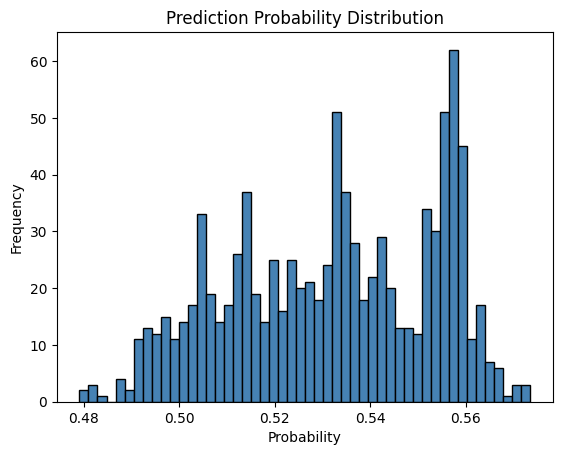

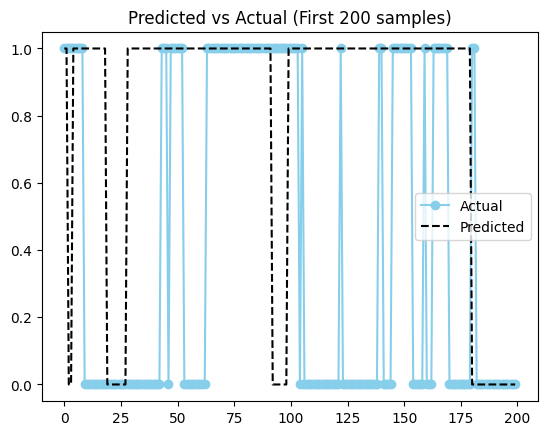

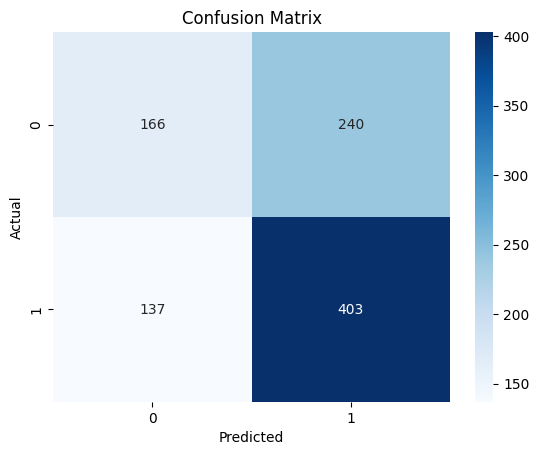

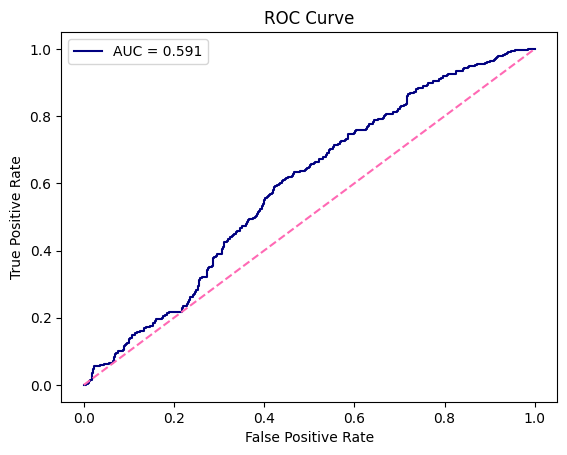

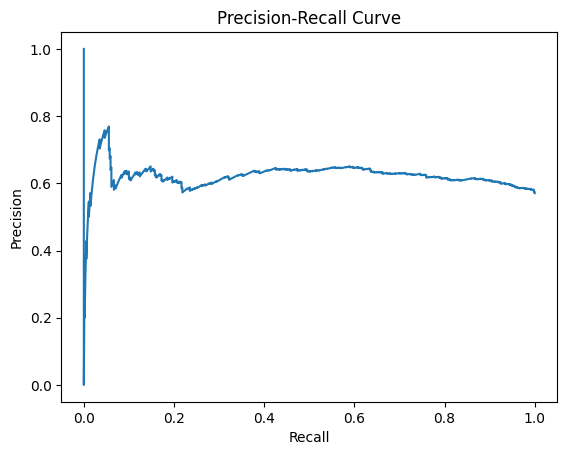


================================ REGRESSION VISUALIZATIONS ================================



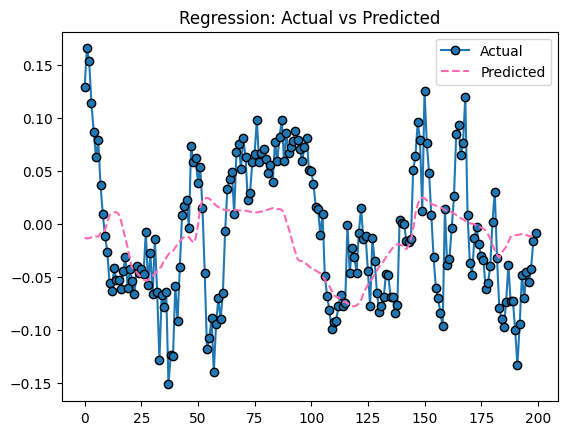



------------------- Regression Metrics --------------------
MAE  : 0.0602
RMSE : 0.0733



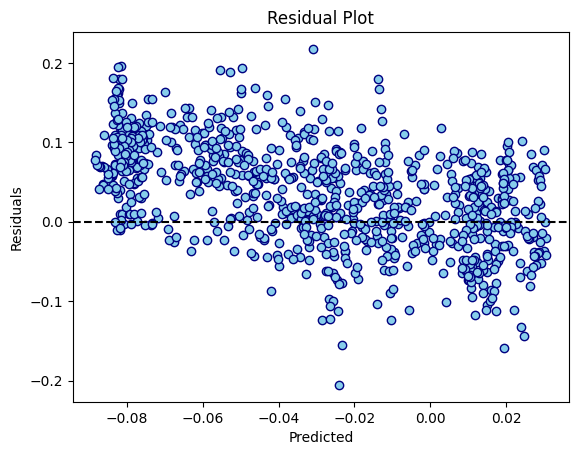



========================================== DEBUG ================================================
Mean Prob : 0.5321
Min Prob  : 0.4791
Max Prob  : 0.5736
Actual UP %: 0.5708
First 20 probs: [0.5040262  0.50242466 0.49873507 0.49905312 0.50176346 0.50526536
 0.5061196  0.5090062  0.5102435  0.5126347  0.5225196  0.53015584
 0.5335652  0.5341498  0.5321685  0.52770865 0.5217889  0.51383513
 0.50461996 0.4961597 ]


In [ ]:
def load_test_data():
    X_test = np.load("X_test.npy")
    y_dir_test = np.load("y_dir_test.npy")
    y_mag_test = np.load("y_mag_test.npy")
    return X_test, y_dir_test, y_mag_test

def test_model():

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load test data
    X_test, y_dir_test, y_mag_test = load_test_data()

    test_dataset = StockDataset(X_test, y_dir_test, y_mag_test)
    test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

    input_size = X_test.shape[2]

    # Load checkpoint (model + config)
    checkpoint = torch.load("best_model_tuned.pth", map_location = device)

    best_config = checkpoint['config']

    # Recreate model EXACTLY as tuned
    model = LSTM_model(
       input_size = input_size,
       hidden_size = best_config['hidden'],
       num_layers = 2,
       dropout = best_config['dropout']
       ).to(device)

    # Load weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_probs = []
    all_labels = []
    all_mag_preds = []
    all_mag_true = []

    # Prediction loop
    with torch.no_grad():
        for X_batch, y_dir_batch, y_mag_batch in test_loader:

            X_batch = X_batch.to(device)

            direction, magnitude = model(X_batch)

            probs = torch.sigmoid(direction.squeeze())

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_dir_batch.numpy())

            all_mag_preds.extend(magnitude.squeeze().cpu().numpy())
            all_mag_true.extend(y_mag_batch.numpy())

    # Convert to numpy
    import numpy as np
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_mag_preds = np.array(all_mag_preds)
    all_mag_true = np.array(all_mag_true)


    # Classification Metrics
    from sklearn.metrics import accuracy_score, balanced_accuracy_score

    y_true = all_labels

    best_score = 0
    best_threshold = 0.5

    for t in np.arange(0.4, 0.8, 0.02):
         preds = (all_probs >= t).astype(int)

         if preds.sum() == 0 or preds.sum() == len(preds):
           continue

         score = balanced_accuracy_score(y_true, preds)

         if score > best_score:
            best_score = score
            best_threshold = t

    print(f"\nBest Threshold: {best_threshold:.2f} | Best Balanced Acc: {best_score:.4f}")
    threshold = best_threshold

    final_preds = (all_probs > threshold).astype(int)
    final_acc = accuracy_score(all_labels, final_preds)

    print("\n================================= TEST RESULTS ========================================")
    print(f"Accuracy: {final_acc:.4f}")
    print(f"Predicted UP: {(final_preds == 1).sum()} | DOWN: {(final_preds == 0).sum()}")

    # Full metrics
    evaluate_metrics(all_probs, all_labels, all_mag_preds, all_mag_true, threshold = threshold)

    # ----- Classification Plots -----
    print("\n================================ CLASSIFICATION VISUALIZATIONS ================================")
    print()
    plot_probability_distribution(all_probs)
    print()
    plot_predictions_vs_actual(all_probs, all_labels)
    print()
    plot_confusion_matrix(all_labels, all_probs, threshold = threshold)
    print()
    plot_roc_curve(all_labels, all_probs)
    print()
    plot_precision_recall(all_labels, all_probs)

    # ----- Regression Plots -----
    print("\n================================ REGRESSION VISUALIZATIONS ================================")
    print()
    plot_regression_predictions(all_mag_true, all_mag_preds)
    print()
    plot_regression_metrics(all_mag_true, all_mag_preds)
    print()
    plot_residuals(all_mag_true, all_mag_preds)
    print()

    # Debug Info
    print("\n========================================== DEBUG ================================================")
    print(f"Mean Prob : {np.mean(all_probs):.4f}")
    print(f"Min Prob  : {np.min(all_probs):.4f}")
    print(f"Max Prob  : {np.max(all_probs):.4f}")
    print(f"Actual UP %: {np.mean(all_labels):.4f}")
    print("First 20 probs:", all_probs[:20])

if __name__ == "__main__":
    test_model()